# Music Listener Segmentation - Model Development

This notebook trains, evaluates, visualizes, and saves a K-Means clustering model using the current `music_listeners (1).csv` dataset.

**Workflow:** Load data -> Validate schema -> Explore features -> Scale data -> Select cluster count -> Train K-Means -> Evaluate -> Visualize segments -> Save artifacts -> Test saved model

## 1. Import Libraries

In [36]:
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme(style="whitegrid")

**Conclusion:** The required analysis, clustering, evaluation, visualization, and model-persistence libraries are available for the workflow.

## 2. Load and Validate the Dataset

The notebook runs from the `ml model` directory, so the dataset is loaded from `../data/music_listeners (1).csv`.

In [37]:
DATA_PATH = Path("../data/music_listeners (1).csv")
GRAPH_DIR = Path("../graphs")
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
FEATURE_COLUMNS = [
    "listening_hours_per_week",
    "songs_per_day",
    "skip_rate",
    "playlist_count",
]

missing_columns = sorted(set(FEATURE_COLUMNS) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
if df[FEATURE_COLUMNS].isnull().any().any():
    raise ValueError("Feature columns contain missing values.")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset loaded successfully.
Dataset shape: (30, 4)
Columns: ['listening_hours_per_week', 'songs_per_day', 'skip_rate', 'playlist_count']


,listening_hours_per_week,songs_per_day,skip_rate,playlist_count
0,2,10,55,2
1,3,15,50,3
2,4,20,60,4
3,5,18,45,3
4,6,22,50,5


**Conclusion:** The dataset contains 30 listener records with all four required features present and no missing feature values, so it is ready for analysis.

## 3. Dataset Overview

Data types:
listening_hours_per_week    int64
songs_per_day               int64
skip_rate                   int64
playlist_count              int64
dtype: object

Summary statistics:


,listening_hours_per_week,songs_per_day,skip_rate,playlist_count
count,30.00,30.00,30.00,30.00
mean,15.17,60.43,29.47,14.97
std,10.80,42.91,18.50,10.77
min,2.00,10.00,3.00,2.00
25%,6.00,22.50,12.75,5.00
50%,12.50,49.00,29.00,14.50
75%,24.25,93.75,45.00,21.50
max,38.00,145.00,65.00,40.00


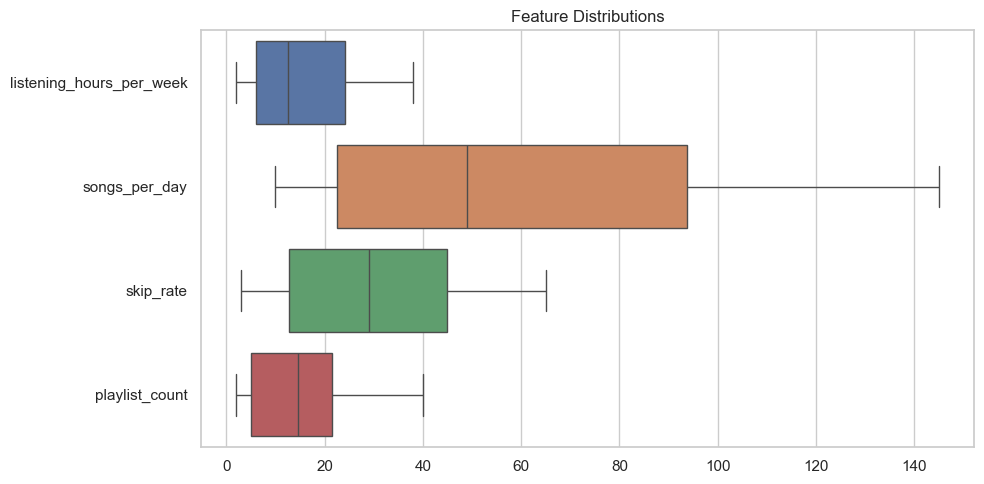

In [38]:
print("Data types:")
print(df[FEATURE_COLUMNS].dtypes)
print("\nSummary statistics:")
display(df[FEATURE_COLUMNS].describe().round(2))

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[FEATURE_COLUMNS], orient="h")
plt.title("Feature Distributions")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusion:** The features have different scales and ranges, confirming that standardization is necessary before distance-based clustering.

## 4. Prepare and Scale Features

Standardization prevents features with larger numeric ranges from dominating the distance-based clustering algorithm.

In [39]:
X = df[FEATURE_COLUMNS].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features:", FEATURE_COLUMNS)
print("Scaled data shape:", X_scaled.shape)

Features: ['listening_hours_per_week', 'songs_per_day', 'skip_rate', 'playlist_count']
Scaled data shape: (30, 4)


**Conclusion:** The four listener-behavior features have been standardized into a 30-row matrix, preventing large-valued features from dominating K-Means distances.

## 5. Select the Number of Clusters

The elbow curve shows how inertia changes with `k`; silhouette score adds a separation/cohesion check. The final model keeps the existing project choice of three clusters.

,Clusters,Inertia,Silhouette Score
0,2,33.4061,0.5779
1,3,14.6092,0.5530
2,4,8.2586,0.5294
3,5,6.0912,0.4625
4,6,4.3698,0.4773
5,7,3.1430,0.4424
6,8,2.4987,0.4337


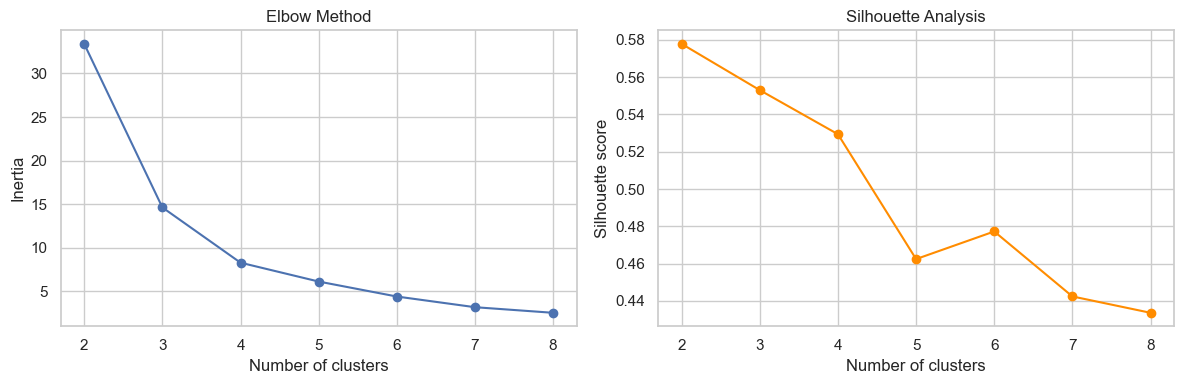

In [40]:
k_values = range(2, min(8, len(X) - 1) + 1)
inertias = []
silhouette_scores = []

for k in k_values:
    candidate = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = candidate.fit_predict(X_scaled)
    inertias.append(candidate.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

selection_df = pd.DataFrame({
    "Clusters": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores,
})
display(selection_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(selection_df["Clusters"], selection_df["Inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")
axes[1].plot(selection_df["Clusters"], selection_df["Silhouette Score"], marker="o", color="darkorange")
axes[1].set_title("Silhouette Analysis")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette score")
fig.tight_layout()
fig.savefig(GRAPH_DIR / "cluster_selection.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusion:** The elbow and silhouette comparisons provide evidence for cluster-count selection. Although the final workflow retains three clusters for project consistency, the scores should be considered alongside the elbow shape and interpretability.

## 6. Train the K-Means Model

In [47]:
N_CLUSTERS = 3
CLUSTER_NAMES = {
    0: "Music Explorer",
    1: "Heavy Listener",
    2: "Casual Listener",
}

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Keep numeric labels for metrics and add readable names for reports and plots.
df_segmented = df.copy()
df_segmented["cluster_id"] = cluster_labels
df_segmented["cluster_name"] = pd.Series(cluster_labels, index=df.index).map(CLUSTER_NAMES)

print(f"K-Means trained with {N_CLUSTERS} clusters.")
print("Named cluster distribution:")
print(df_segmented["cluster_name"].value_counts().reindex(CLUSTER_NAMES.values()))

K-Means trained with 3 clusters.
Named cluster distribution:
cluster_name
Music Explorer     11
Heavy Listener      8
Casual Listener    11
Name: count, dtype: int64


**Conclusion:** The K-Means model successfully partitions the listeners into three named segments: Music Explorer (11 listeners), Heavy Listener (8 listeners), and Casual Listener (11 listeners).

## 7. Evaluate Clustering Quality

These unsupervised metrics assess the fitted segments without requiring a target label. Higher silhouette and Calinski-Harabasz scores are generally better; lower Davies-Bouldin is generally better.

In [48]:
evaluation = pd.DataFrame([
    {
        "Clusters": N_CLUSTERS,
        "Inertia": kmeans.inertia_,
        "Silhouette Score": silhouette_score(X_scaled, cluster_labels),
        "Calinski-Harabasz Score": calinski_harabasz_score(X_scaled, cluster_labels),
        "Davies-Bouldin Score": davies_bouldin_score(X_scaled, cluster_labels),
    }
])
display(evaluation.round(4))

cluster_counts = df_segmented["cluster_name"].value_counts().reindex(CLUSTER_NAMES.values()).rename("Listeners")
cluster_counts.to_frame()

,Clusters,Inertia,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,3,14.6092,0.553,97.3887,0.5202


,Listeners
cluster_name,
Music Explorer,11
Heavy Listener,8
Casual Listener,11


**Conclusion:** The three-cluster solution has a silhouette score of approximately 0.553, a Calinski-Harabasz score of approximately 97.389, and a Davies-Bouldin score of approximately 0.520. These indicate reasonably separated and compact segments for this dataset.

## 8. Inspect Cluster Profiles

Cluster profiles in original feature units:


,listening_hours_per_week,songs_per_day,skip_rate,playlist_count
cluster_name,,,,
Casual Listener,4.82,19.09,49.82,4.09
Music Explorer,14.45,58.00,24.91,15.64
Heavy Listener,30.38,120.62,7.75,29.00


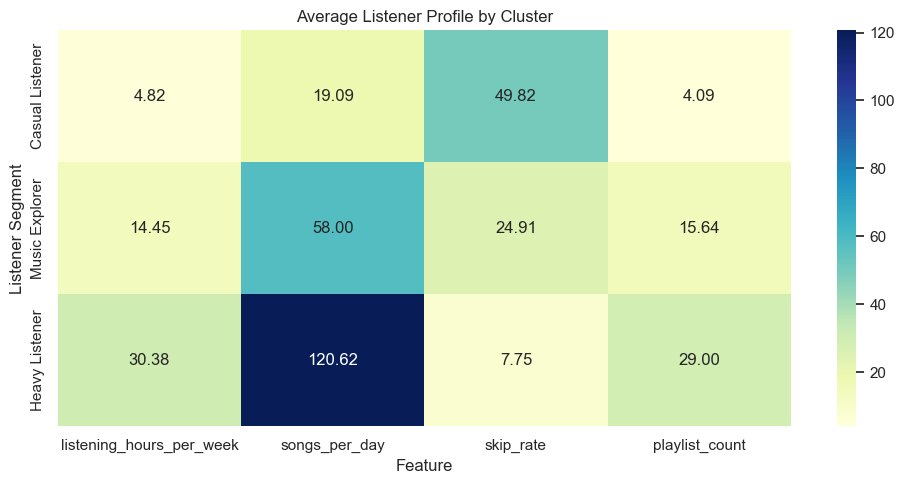

In [49]:
cluster_profiles = df_segmented.groupby("cluster_name", sort=False)[FEATURE_COLUMNS].mean().round(2)
print("Cluster profiles in original feature units:")
display(cluster_profiles)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Listener Profile by Cluster")
plt.xlabel("Feature")
plt.ylabel("Listener Segment")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusion:** The named profiles show distinct listener behaviors: Casual Listener has the lowest activity and highest skip rate, Music Explorer is moderate across the features, and Heavy Listener has the highest activity and lowest skip rate.

## 9. Visualize the Segments

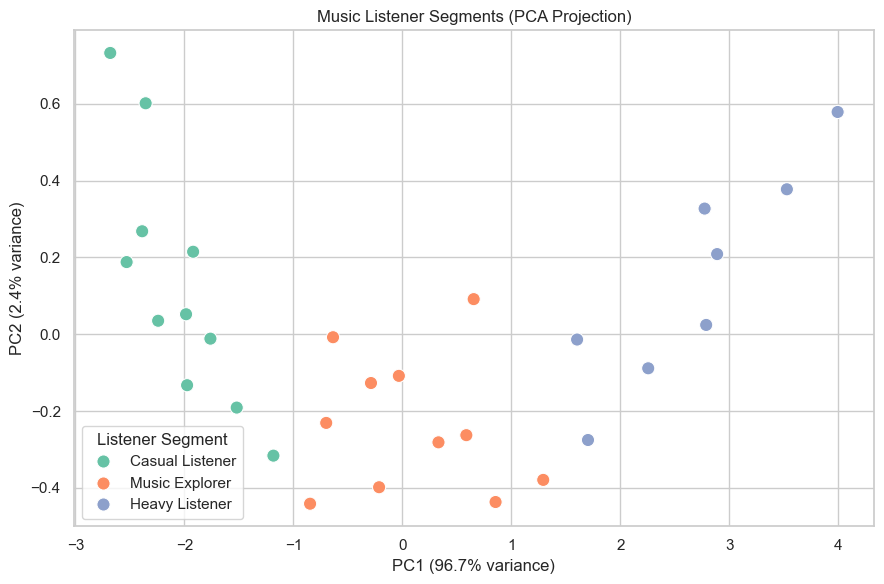

In [50]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Listener Segment": pd.Series(cluster_labels, index=df.index).map(CLUSTER_NAMES),
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Listener Segment", palette="Set2", s=90, legend="full")
plt.title("Music Listener Segments (PCA Projection)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Listener Segment")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "cluster_segments_pca.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusion:** The PCA projection provides a two-dimensional visual check of the segments and shows how the three groups are positioned relative to one another after scaling.

## 10. Save the Model and Scaler

In [53]:
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "model.pkl"
SCALER_PATH = MODEL_DIR / "scaler.pkl"
CLUSTER_NAMES_PATH = MODEL_DIR / "cluster_names.pkl"
EVALUATION_PATH = MODEL_DIR / "cluster_evaluation.csv"
PROFILES_PATH = MODEL_DIR / "cluster_profiles.csv"

joblib.dump(kmeans, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(CLUSTER_NAMES, CLUSTER_NAMES_PATH)
evaluation.to_csv(EVALUATION_PATH, index=False)
cluster_profiles.to_csv(PROFILES_PATH)

print("Files saved successfully:")
for path in [MODEL_PATH, SCALER_PATH, CLUSTER_NAMES_PATH, EVALUATION_PATH, PROFILES_PATH]:
    print(path.resolve())

Files saved successfully:
D:\Workplace\Capstone-Project\Unsupervised_Learning\Music_Listener_Segmentation\ml model\models\model.pkl
D:\Workplace\Capstone-Project\Unsupervised_Learning\Music_Listener_Segmentation\ml model\models\scaler.pkl
D:\Workplace\Capstone-Project\Unsupervised_Learning\Music_Listener_Segmentation\ml model\models\cluster_names.pkl
D:\Workplace\Capstone-Project\Unsupervised_Learning\Music_Listener_Segmentation\ml model\models\cluster_evaluation.csv
D:\Workplace\Capstone-Project\Unsupervised_Learning\Music_Listener_Segmentation\ml model\models\cluster_profiles.csv


**Conclusion:** The trained K-Means model, scaler, cluster-name mapping, evaluation metrics, and named cluster profiles were saved successfully for reuse by the application or backend.

## 11. Test the Saved Model

This confirms that the saved K-Means model and scaler can assign a new listener to a segment.

In [54]:
loaded_model = joblib.load(MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)
loaded_cluster_names = joblib.load(CLUSTER_NAMES_PATH)

new_listener = pd.DataFrame([{
    "listening_hours_per_week": 6,
    "songs_per_day": 24,
    "skip_rate": 45,
    "playlist_count": 5,
}])[FEATURE_COLUMNS]

new_listener_scaled = loaded_scaler.transform(new_listener)
predicted_cluster_id = int(loaded_model.predict(new_listener_scaled)[0])
predicted_cluster_name = loaded_cluster_names[predicted_cluster_id]
distances = loaded_model.transform(new_listener_scaled)[0]

print("New listener:")
display(new_listener)
print(f"Assigned cluster ID: {predicted_cluster_id}")
print(f"Assigned listener segment: {predicted_cluster_name}")
print("Distance to each cluster center:", np.round(distances, 3))

New listener:


,listening_hours_per_week,songs_per_day,skip_rate,playlist_count
0,6,24,45,5


Assigned cluster ID: 2
Assigned listener segment: Casual Listener
Distance to each cluster center: [1.874 4.456 0.322]


**Conclusion:** The saved model and scaler can process a new listener consistently, while the saved mapping converts the numeric prediction into a readable listener segment name.

## 12. ML Handoff

The trained artifacts are ready for backend integration.

### Output
- `models/model.pkl` - trained K-Means clustering model
- `models/scaler.pkl` - feature standardization object
- `models/cluster_names.pkl` - mapping from numeric cluster IDs to readable segment names
- `models/cluster_evaluation.csv` - clustering quality metrics
- `models/cluster_profiles.csv` - average feature values by named cluster
- `../graphs/` - saved evaluation and segmentation plots

### Segment names
- Cluster 2 -> Casual Listener
- Cluster 0 -> Music Explorer
- Cluster 1 -> Heavy Listener

### Backend flow
`Listener Input -> Scaler -> K-Means Model -> Cluster ID -> Listener Segment Name`